In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as skm
import datetime as dt
import boto3
import pickle
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')

try:
    import catboost as cb
except:
    ! pip install catboost

In [2]:
print(f'Latest run date: {dt.datetime.now()}')

Latest run date: 2024-03-14 22:18:52.912466


### Functions

In [3]:
def show_distribution(df, str_col):
    int_n = df.shape[0]
    flt_min = df[str_col].min()
    flt_max = df[str_col].max()
    flt_mean = df[str_col].mean()
    flt_sd = df[str_col].std()
    flt_mdn = df[str_col].median()
    str_title = f"""
    Distribution of {str_col} (N = {int_n})
    Min = {flt_min:0.4f}; Max = {flt_max:0.4f}; Mean = {flt_mean:0.4f}; SD = {flt_sd:0.4f}; Mdn = {flt_mdn:0.4f}
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_col)
    sns.kdeplot(list(df[str_col]), ax=ax)
    plt.show()

In [4]:
def visualize_relation(df, str_x):
    flt_r, flt_p = pearsonr(df[str_x], df['target'])
    str_title = f"""
    Relation between {str_x} and Target
    r = {flt_r:0.4f}; p = {flt_p:0.4f}
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_x)
    ax.set_ylabel('Target')
    ax.scatter(df[str_x], df['target'])
    plt.show()

In [5]:
def plot_over_time(df, str_col):
    str_title = f"""
    Average {str_col} over time
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel('applicationdate__app')
    ax.set_ylabel(str_col)
    ax.plot(df['applicationdate__app'], df[str_col])
    ax.set_xticklabels(df['applicationdate__app'], rotation=45)
    plt.show()

In [6]:
def train_test_split(df, flt_prop_train):
    df['row'] = list(range(1, df.shape[0]+1))
    df['prop_row'] = df['row'] / df.shape[0]
    df['data_set'] = df['prop_row'].apply(
        lambda x: 'Train' if x <= flt_prop_train else 'Test',
    )
    df.drop(['row','prop_row'], axis=1, inplace=True)
    return df

In [7]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

### Constants

In [8]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'
flt_loss_buffer = 0.025
flt_pd_buffer = 0.025

# months (production data goes from 2021-01-25 to 2024-03-04)
list_str_year_month = [
    '2021-01',
    '2021-02',
    '2021-03',
    '2021-04',
    '2021-05',
    '2021-06',
    '2021-07',
    '2021-08',
    '2021-09',
    '2021-10',
    '2021-11',
    '2021-12',
    '2022-01',
    '2022-02',
#     '2022-03',
#     '2022-04',
#     '2022-05',
#     '2022-06',
#     '2022-07',
#     '2022-08',
#     '2022-09',
#     '2022-10',
#     '2022-11',
#     '2022-12',
#     '2023-01',
#     '2023-02',
#     '2023-03',
#     '2023-04',
#     '2023-05',
#     '2023-06',
#     '2023-07',
#     '2023-08',
#     '2023-09',
#     '2023-10',
#     '2023-11',
#     '2023-12',
#     '2024-01',
#     '2024-02',
#     '2024-03',
]
# note: production targets were pulled 2024-03-06
# maximum days total of the targets is 720
# thus, to ensure all accounts have been 720 days (24 months) mature, I have subsetted to the latest date being 2022-02
# we can edit this as needed

Project: 20231010-gen-xii
Task: 09_early_indicators


### Output directory

In [9]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [10]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get PD model

In [11]:
# get PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'02_pricing_pd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_pd = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_pd = list(cls_model_inference_pd.feature_names_)

### Get LGD model

In [12]:
# get PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'03_pricing_lgd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_lgd = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_lgd = list(cls_model_inference_lgd.feature_names_)

### Get preprocessor

In [13]:
# preprocess
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

100%|██████████| 2/2 [00:00<00:00,  8.38it/s]


### Get loss target pulled from DB recently

In [14]:
# get targets
list_cols = [
    'bigAccountId',
    'fltNetChgOff',
]
str_filename = 'df_loss.csv'
str_uri = f's3://{str_project}/ad_hoc/linear_ecnl_transformation/02_forecasted_averages/{str_filename}'
df_target = pd.read_csv(
    str_uri, 
    usecols=list_cols,
)
dict_rename = {
    'fltNetChgOff': 'target',
}
df_target.rename(columns=dict_rename, inplace=True)

# get mean
flt_mean_target = df_target['target'].mean()
print(f'The mean of the target in all loans is {flt_mean_target:0.4f}')
# show
df_target

The mean of the target in all loans is 2320.2147


,bigAccountId,target
0,270838,2851.77
1,270852,2350.55
2,270777,3660.45
3,270795,5853.88
4,270811,3942.34
...,...,...
413519,10130,0.00
413520,23114,0.00
413521,61972,0.00
413522,76430,0.00


### Get PD training data

In [15]:
%%time

# load pd train data
str_filename = 'df_train_raw.gzip'
str_uri = f's3://{str_project}/02_pricing_pd/01_data_prep/03_train_valid_test_split/old/{str_filename}'
df_train = pd.read_parquet(str_uri)
df_train['uniqueid'] = df_train['uniqueid'].astype(int)
df_train.drop_duplicates(subset='uniqueid', keep='last', inplace=True)
# set as int for joining
df_train['bigaccountid__app'] = df_train['bigaccountid__app'].astype(int)
# preprocess
df_train = cls_model_preprocessing.transform(df_train)
# predict PD
df_train['yhat_pd'] = cls_model_inference_pd.predict_proba(df_train[list_cols_model_pd])[:, 1]
# predict LGD
df_train['yhat_lgd'] = cls_model_inference_lgd.predict(df_train[list_cols_model_lgd])
# convert applicationdate to first of the month
df_train['applicationdate__app'] = df_train['applicationdate__app'].dt.to_period('M').dt.to_timestamp().astype(str)
# show
df_train

NaN Replacer: 1.4984 sec.


100%|██████████| 3/3 [00:00<00:00, 50.84it/s]

Set strings: 0.061205 sec.


Boolean Replacer: 1.6198 sec.


100%|██████████| 2478/2478 [00:01<00:00, 1586.71it/s]


...

Replace inf and -inf with NaN: 2.459 sec.
Imputer: 1.1077 sec.
Map term: 0.030094 sec.
Map PTI: 0.031464 sec.


100%|██████████| 9/9 [00:00<00:00, 1264.57it/s]

Round values: 0.010924 sec.
Preprocessing Model: 13.512 sec.


CPU times: user 16.9 s, sys: 5.01 s, total: 21.9 s
Wall time: 16.3 s


,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,open_dte__base,curr_bal_amt__base,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,yhat_pd,yhat_lgd
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,0.513062,0.419317
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.310533,0.346931
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.03,1.342857,1.0,3.961644,0.706639,0.471772
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.12,1.588235,2.0,0.838356,0.448451,0.360220
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.12,1.037037,0.0,3.613699,0.241002,0.434562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74583,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2016,1.219360,3,1,0.15,1.482759,1.0,12.701370,0.689931,0.461088
74584,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2016,1.219360,3,1,0.15,1.222222,3.0,8.498630,0.172488,0.306691
74586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2016,1.219360,3,1,0.09,1.343750,1.0,3.890411,0.240983,0.263744
74587,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2016,1.219360,3,1,0.09,1.240000,5.0,4.030137,0.310571,0.312804


### Group by account

In [16]:
# group to simulate the API
df_train = df_train.groupby(by='bigaccountid__app', as_index=False).agg({
    'applicationdate__app': 'first',
    'intopenbktype__app': 'first',
    'amtfinanced__app': 'first',
    'yhat_pd': 'mean',
    'yhat_lgd': 'mean',
})
# get ecnl
df_train['ecnl'] = df_train['yhat_pd'] * df_train['yhat_lgd']
# get target from db
df_train = pd.merge(
    left=df_train,
    right=df_target,
    left_on='bigaccountid__app',
    right_on='bigAccountId',
    how='inner',
)
# turn target into a proportion
df_train['target'] = df_train['target'] / df_train['amtfinanced__app']
# drop account
df_train.drop('bigAccountId', axis=1, inplace=True)
df_train

,bigaccountid__app,applicationdate__app,intopenbktype__app,amtfinanced__app,yhat_pd,yhat_lgd,ecnl,target
0,1337511.0,2013-10-01,nan,18500.0,0.513062,0.419317,0.215136,0.478315
1,1337528.0,2013-10-01,7.0,23000.0,0.310533,0.346931,0.107734,0.375580
2,1337539.0,2013-10-01,nan,23500.0,0.706639,0.471772,0.333372,0.419301
3,1337542.0,2013-10-01,nan,27000.0,0.448451,0.360220,0.161541,0.526894
4,1337547.0,2013-10-01,7.0,28000.0,0.241002,0.434562,0.104730,0.000000
...,...,...,...,...,...,...,...,...
59036,2493925.0,2016-03-01,7.0,21500.0,0.689931,0.461088,0.318119,0.445742
59037,2493958.0,2016-03-01,7.0,38500.0,0.172488,0.306691,0.052900,0.331840
59038,2493969.0,2016-03-01,nan,21500.0,0.240983,0.263744,0.063558,0.000000
59039,2493994.0,2016-03-01,13.0,15500.0,0.310571,0.312804,0.097148,0.000000


### Show distributions

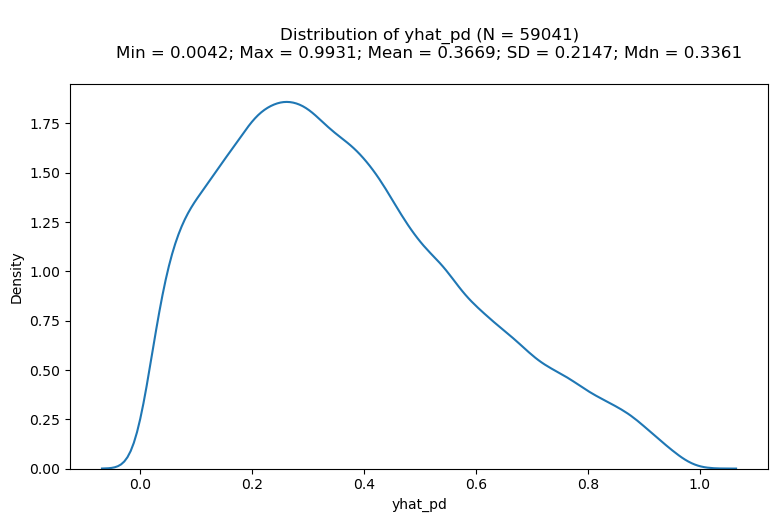

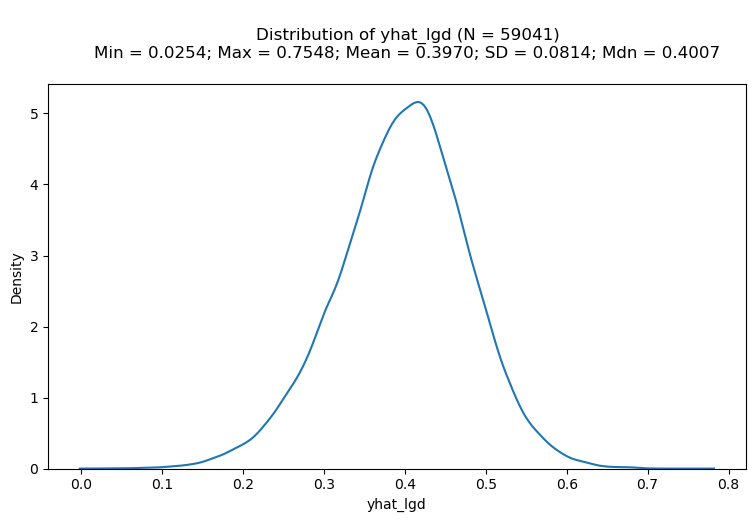

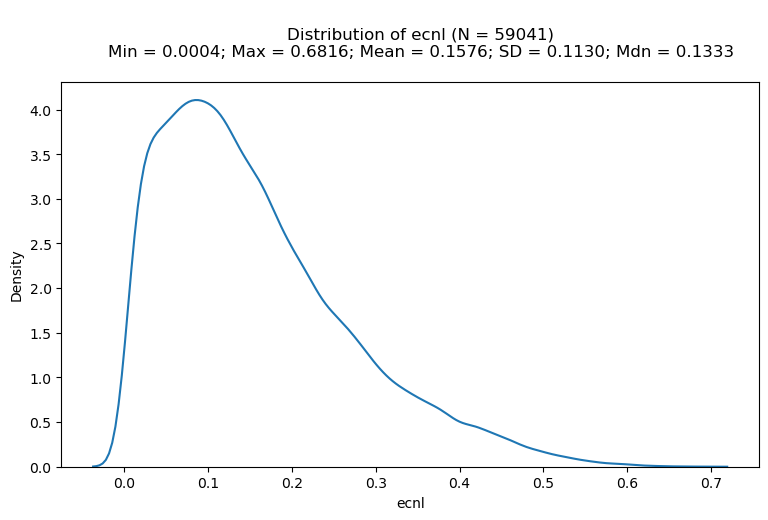

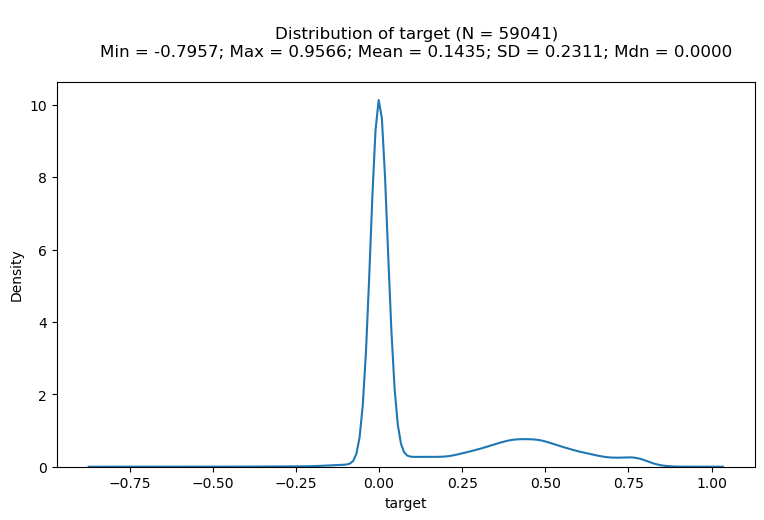

In [17]:
list_str_col = [
    'yhat_pd',
    'yhat_lgd',
    'ecnl',
    'target',
]
for str_col in list_str_col:
    show_distribution(
        df=df_train, 
        str_col=str_col,
    )

### Visualize relationships between predictions and target

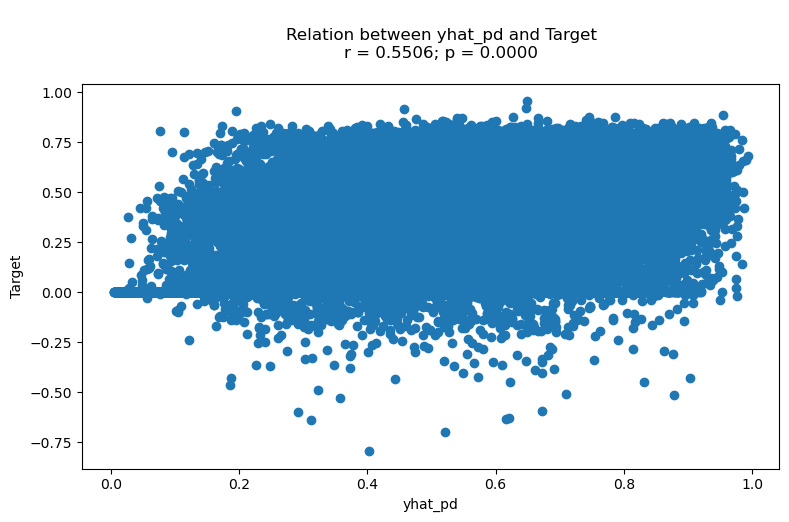

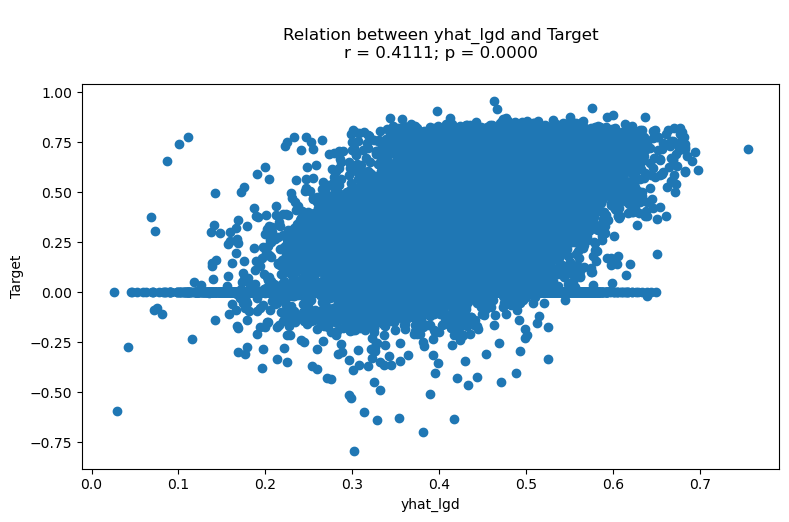

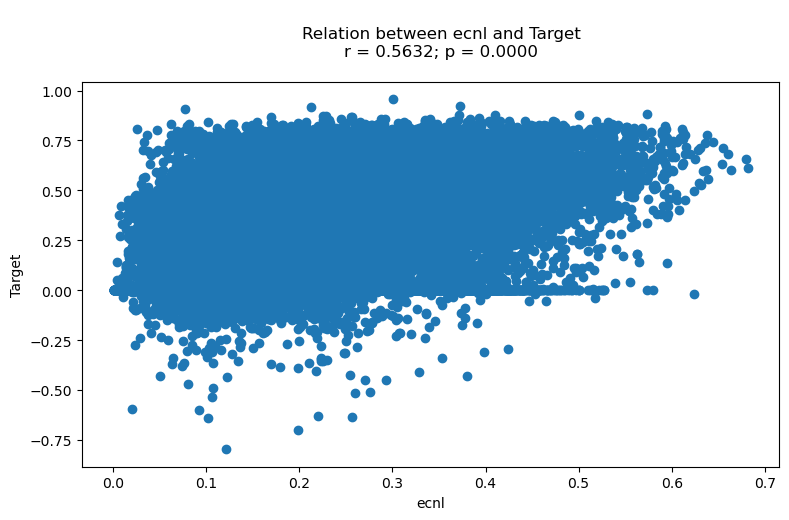

In [18]:
list_str_x = [
    'yhat_pd',
    'yhat_lgd',
    'ecnl',
]
for str_x in list_str_x:
    visualize_relation(
        df=df_train, 
        str_x=str_x,
    )

### Evaluate loss using LGD model and an LGD constant

In [19]:
flt_mean_loss = df_train['target'].mean()
print(f'Mean actual loss: {flt_mean_loss:0.4f}')
flt_mean_ecnl_w_lgd = df_train['ecnl'].mean()
print(f'Mean ECNL using LGD model: {flt_mean_ecnl_w_lgd:0.4f}')
flt_mean_pd = df_train['yhat_pd'].mean()
print(f'Mean PD: {flt_mean_pd:0.4f}')
# solve for LGD
flt_lgd_constant = flt_mean_loss / flt_mean_pd
print(f'LGD Constant: {flt_lgd_constant:0.4f}')
df_train['lgd_constant'] = flt_lgd_constant
df_train['ecnl_w_constant'] = df_train['yhat_pd'] * df_train['lgd_constant']
flt_mean_ecnl_w_constant = df_train['ecnl_w_constant'].mean()
print(f'Mean ECNL using LGD constant: {flt_mean_ecnl_w_constant:0.4f}')
df_train

Mean actual loss: 0.1435
Mean ECNL using LGD model: 0.1576
Mean PD: 0.3669
LGD Constant: 0.3911
Mean ECNL using LGD constant: 0.1435


,bigaccountid__app,applicationdate__app,intopenbktype__app,amtfinanced__app,yhat_pd,yhat_lgd,ecnl,target,lgd_constant,ecnl_w_constant
0,1337511.0,2013-10-01,nan,18500.0,0.513062,0.419317,0.215136,0.478315,0.39107,0.200643
1,1337528.0,2013-10-01,7.0,23000.0,0.310533,0.346931,0.107734,0.375580,0.39107,0.121440
2,1337539.0,2013-10-01,nan,23500.0,0.706639,0.471772,0.333372,0.419301,0.39107,0.276345
3,1337542.0,2013-10-01,nan,27000.0,0.448451,0.360220,0.161541,0.526894,0.39107,0.175376
4,1337547.0,2013-10-01,7.0,28000.0,0.241002,0.434562,0.104730,0.000000,0.39107,0.094249
...,...,...,...,...,...,...,...,...,...,...
59036,2493925.0,2016-03-01,7.0,21500.0,0.689931,0.461088,0.318119,0.445742,0.39107,0.269811
59037,2493958.0,2016-03-01,7.0,38500.0,0.172488,0.306691,0.052900,0.331840,0.39107,0.067455
59038,2493969.0,2016-03-01,nan,21500.0,0.240983,0.263744,0.063558,0.000000,0.39107,0.094241
59039,2493994.0,2016-03-01,13.0,15500.0,0.310571,0.312804,0.097148,0.000000,0.39107,0.121455


## POC forecasting

### Examine trends over time

In [20]:
# plot averages over time
df_grouped = df_train.groupby(by='applicationdate__app', as_index=False).agg({
    'yhat_pd': 'mean',
    'yhat_lgd': 'mean',
    'ecnl': 'mean',
    'target': 'mean',
})
df_grouped

,applicationdate__app,yhat_pd,yhat_lgd,ecnl,target
0,2013-10-01,0.356213,0.389521,0.149945,0.131224
1,2013-11-01,0.353146,0.390076,0.148849,0.127938
2,2013-12-01,0.359077,0.390350,0.150627,0.126057
3,2014-01-01,0.357323,0.391788,0.151134,0.124857
4,2014-02-01,0.350386,0.392263,0.148774,0.129274
5,2014-03-01,0.361184,0.392701,0.152903,0.138351
6,2014-04-01,0.365366,0.393350,0.155275,0.150223
7,2014-05-01,0.353295,0.390214,0.150158,0.139077
8,2014-06-01,0.358406,0.390075,0.152263,0.139677
9,2014-07-01,0.357606,0.391659,0.152810,0.138553


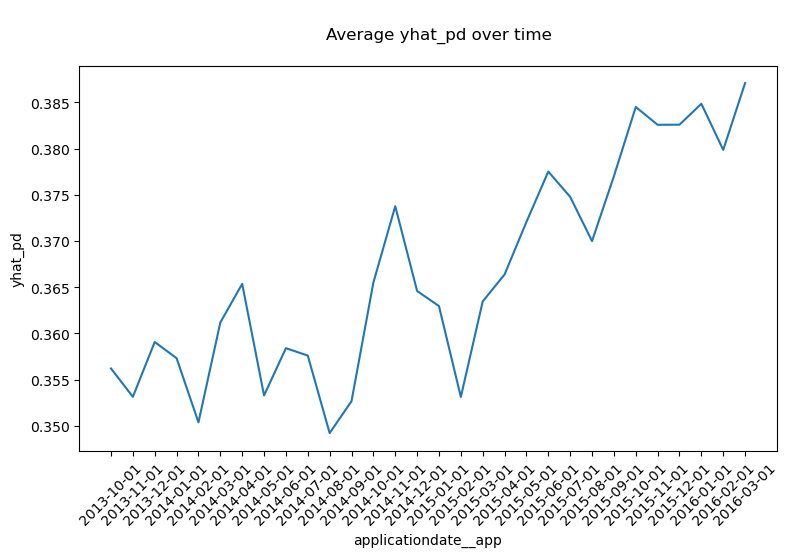

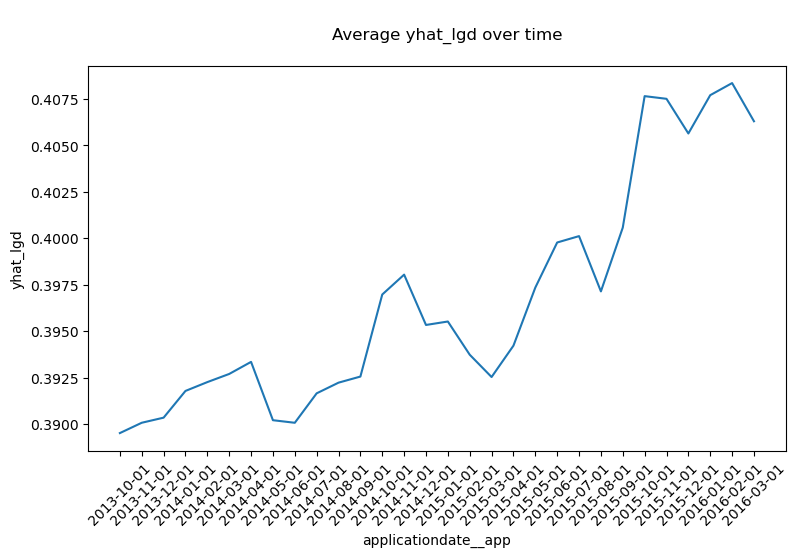

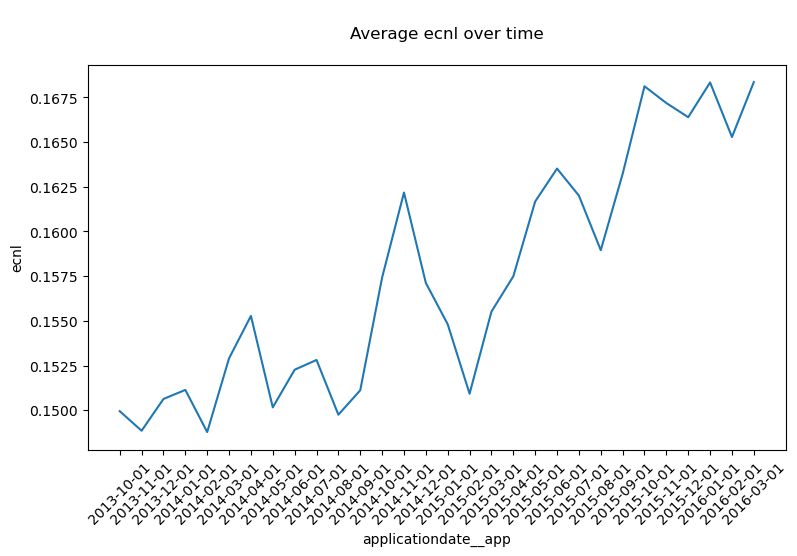

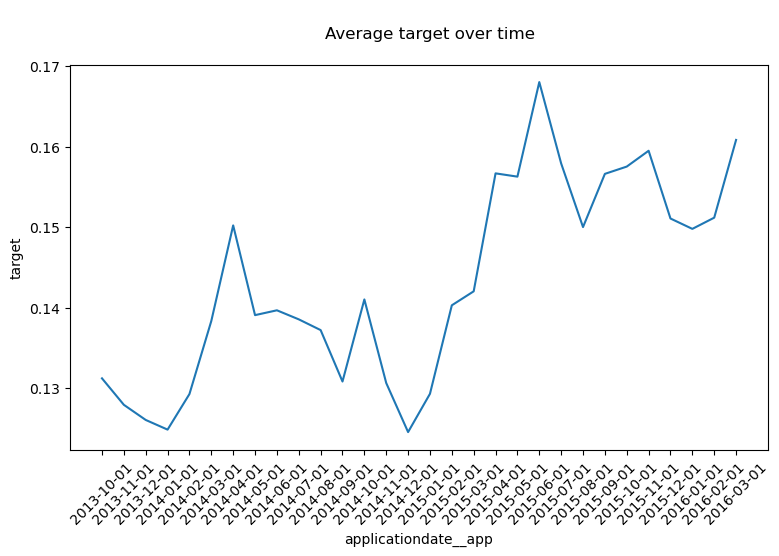

In [21]:
list_str_col = [
    'yhat_pd',
    'yhat_lgd',
    'ecnl',
    'target',
]
for str_col in list_str_col:
    plot_over_time(
        df=df_grouped, 
        str_col=str_col,
    )

### Train, test split

In [22]:
# train, test split
df_grouped = train_test_split(
    df=df_grouped,
    flt_prop_train=0.75,
)
df_grouped['month_number'] = list(range(1, df_grouped.shape[0]+1))
df_grouped

,applicationdate__app,yhat_pd,yhat_lgd,ecnl,target,data_set,month_number
0,2013-10-01,0.356213,0.389521,0.149945,0.131224,Train,1
1,2013-11-01,0.353146,0.390076,0.148849,0.127938,Train,2
2,2013-12-01,0.359077,0.390350,0.150627,0.126057,Train,3
3,2014-01-01,0.357323,0.391788,0.151134,0.124857,Train,4
4,2014-02-01,0.350386,0.392263,0.148774,0.129274,Train,5
5,2014-03-01,0.361184,0.392701,0.152903,0.138351,Train,6
6,2014-04-01,0.365366,0.393350,0.155275,0.150223,Train,7
7,2014-05-01,0.353295,0.390214,0.150158,0.139077,Train,8
8,2014-06-01,0.358406,0.390075,0.152263,0.139677,Train,9
9,2014-07-01,0.357606,0.391659,0.152810,0.138553,Train,10


### Forecast the actual loss because we will need it to get a forecasted LGD constant

In [23]:
# fit simple linear regression model to forecast actual loss
cls_model = LinearRegression()
list_cols = [
    'month_number'
]
X = df_grouped[df_grouped['data_set'] == 'Train'].copy()[list_cols]
y = df_grouped[df_grouped['data_set'] == 'Train'].copy()['target']
cls_model.fit(X, y)
# predict
X_tmp = df_grouped[df_grouped['data_set'] == 'Test'].copy()[list_cols]
X_tmp['yhat_loss'] = list(cls_model.predict(X_tmp))
X_tmp['yhat_loss'] = X_tmp['yhat_loss'] + flt_loss_buffer
# join
df_grouped = pd.merge(
    left=df_grouped,
    right=X_tmp,
    on='month_number',
    how='left',
)
df_grouped

,applicationdate__app,yhat_pd,yhat_lgd,ecnl,target,data_set,month_number,yhat_loss
0,2013-10-01,0.356213,0.389521,0.149945,0.131224,Train,1,NaN
1,2013-11-01,0.353146,0.390076,0.148849,0.127938,Train,2,NaN
2,2013-12-01,0.359077,0.390350,0.150627,0.126057,Train,3,NaN
3,2014-01-01,0.357323,0.391788,0.151134,0.124857,Train,4,NaN
4,2014-02-01,0.350386,0.392263,0.148774,0.129274,Train,5,NaN
5,2014-03-01,0.361184,0.392701,0.152903,0.138351,Train,6,NaN
6,2014-04-01,0.365366,0.393350,0.155275,0.150223,Train,7,NaN
7,2014-05-01,0.353295,0.390214,0.150158,0.139077,Train,8,NaN
8,2014-06-01,0.358406,0.390075,0.152263,0.139677,Train,9,NaN
9,2014-07-01,0.357606,0.391659,0.152810,0.138553,Train,10,NaN


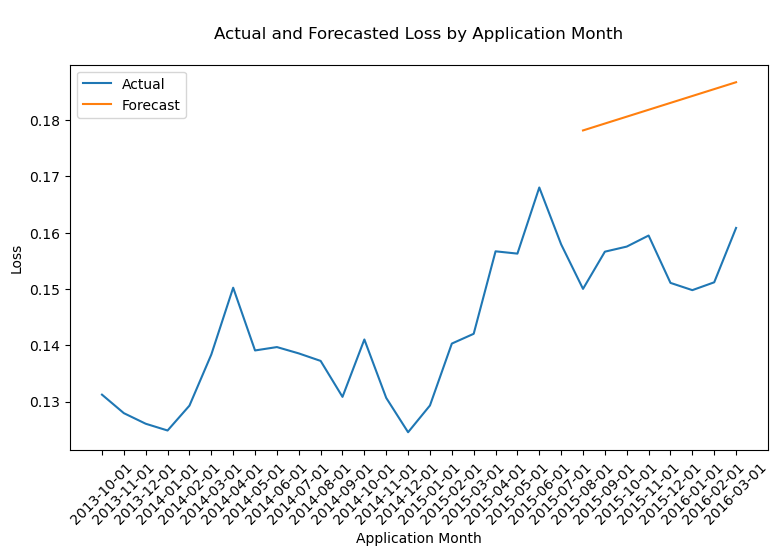

In [24]:
# plot
str_title = f"""
Actual and Forecasted Loss by Application Month
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Application Month')
ax.set_ylabel('Loss')
ax.plot(df_grouped['applicationdate__app'], df_grouped['target'], label='Actual')
ax.plot(df_grouped['applicationdate__app'], df_grouped['yhat_loss'], label='Forecast')
ax.set_xticklabels(df_grouped['applicationdate__app'], rotation=45)
plt.legend()
plt.show()

### Forecast the PD score from the model because we will need it to get a forecasted LGD constant

In [25]:
# fit simple linear regression model to forecast pd
cls_model = LinearRegression()
list_cols = [
    'month_number'
]
X = df_grouped[df_grouped['data_set'] == 'Train'].copy()[list_cols]
y = df_grouped[df_grouped['data_set'] == 'Train'].copy()['yhat_pd']
cls_model.fit(X, y)
# predict
X_tmp = df_grouped[df_grouped['data_set'] == 'Test'].copy()[list_cols]
X_tmp['yhat_yhat_pd'] = list(cls_model.predict(X_tmp))
X_tmp['yhat_yhat_pd'] = X_tmp['yhat_yhat_pd'] + flt_pd_buffer
# join
df_grouped = pd.merge(
    left=df_grouped,
    right=X_tmp,
    on='month_number',
    how='left',
)
df_grouped

,applicationdate__app,yhat_pd,yhat_lgd,ecnl,target,data_set,month_number,yhat_loss,yhat_yhat_pd
0,2013-10-01,0.356213,0.389521,0.149945,0.131224,Train,1,NaN,NaN
1,2013-11-01,0.353146,0.390076,0.148849,0.127938,Train,2,NaN,NaN
2,2013-12-01,0.359077,0.390350,0.150627,0.126057,Train,3,NaN,NaN
3,2014-01-01,0.357323,0.391788,0.151134,0.124857,Train,4,NaN,NaN
4,2014-02-01,0.350386,0.392263,0.148774,0.129274,Train,5,NaN,NaN
5,2014-03-01,0.361184,0.392701,0.152903,0.138351,Train,6,NaN,NaN
6,2014-04-01,0.365366,0.393350,0.155275,0.150223,Train,7,NaN,NaN
7,2014-05-01,0.353295,0.390214,0.150158,0.139077,Train,8,NaN,NaN
8,2014-06-01,0.358406,0.390075,0.152263,0.139677,Train,9,NaN,NaN
9,2014-07-01,0.357606,0.391659,0.152810,0.138553,Train,10,NaN,NaN


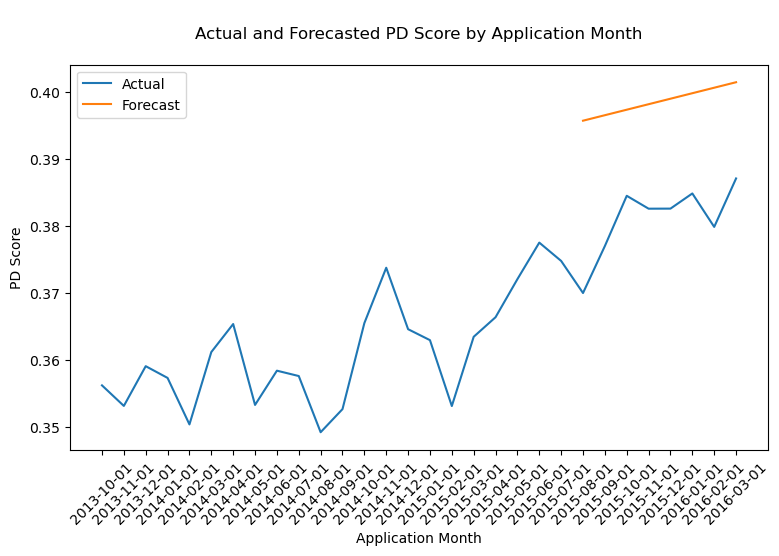

In [26]:
# plot
str_title = f"""
Actual and Forecasted PD Score by Application Month
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Application Month')
ax.set_ylabel('PD Score')
ax.plot(df_grouped['applicationdate__app'], df_grouped['yhat_pd'], label='Actual')
ax.plot(df_grouped['applicationdate__app'], df_grouped['yhat_yhat_pd'], label='Forecast')
ax.set_xticklabels(df_grouped['applicationdate__app'], rotation=45)
plt.legend()
plt.show()

### Get the forecasted LGD constant using forecasted loss and forecasted PD score

In [27]:
# get the lgd constant (actual)
df_grouped['lgd_constant'] = df_grouped['target'] / df_grouped['yhat_pd']
# get forecasted lgd constant
df_grouped['yhat_lgd_constant'] = df_grouped['yhat_loss'] / df_grouped['yhat_yhat_pd']
# show
df_grouped

,applicationdate__app,yhat_pd,yhat_lgd,ecnl,target,data_set,month_number,yhat_loss,yhat_yhat_pd,lgd_constant,yhat_lgd_constant
0,2013-10-01,0.356213,0.389521,0.149945,0.131224,Train,1,NaN,NaN,0.368388,NaN
1,2013-11-01,0.353146,0.390076,0.148849,0.127938,Train,2,NaN,NaN,0.362281,NaN
2,2013-12-01,0.359077,0.390350,0.150627,0.126057,Train,3,NaN,NaN,0.351059,NaN
3,2014-01-01,0.357323,0.391788,0.151134,0.124857,Train,4,NaN,NaN,0.349422,NaN
4,2014-02-01,0.350386,0.392263,0.148774,0.129274,Train,5,NaN,NaN,0.368947,NaN
5,2014-03-01,0.361184,0.392701,0.152903,0.138351,Train,6,NaN,NaN,0.383048,NaN
6,2014-04-01,0.365366,0.393350,0.155275,0.150223,Train,7,NaN,NaN,0.411156,NaN
7,2014-05-01,0.353295,0.390214,0.150158,0.139077,Train,8,NaN,NaN,0.393656,NaN
8,2014-06-01,0.358406,0.390075,0.152263,0.139677,Train,9,NaN,NaN,0.389718,NaN
9,2014-07-01,0.357606,0.391659,0.152810,0.138553,Train,10,NaN,NaN,0.387445,NaN


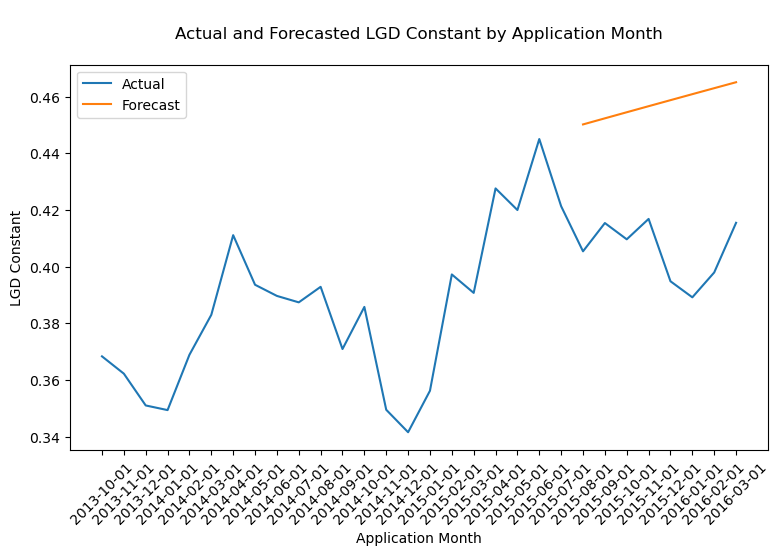

In [28]:
# plot
str_title = f"""
Actual and Forecasted LGD Constant by Application Month
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Application Month')
ax.set_ylabel('LGD Constant')
ax.plot(df_grouped['applicationdate__app'], df_grouped['lgd_constant'], label='Actual')
ax.plot(df_grouped['applicationdate__app'], df_grouped['yhat_lgd_constant'], label='Forecast')
ax.set_xticklabels(df_grouped['applicationdate__app'], rotation=45)
plt.legend()
plt.show()

### Get the forecasted loss for pricing using the forecasted PD score and forecasted LGD constant

In [29]:
# get the predicted loss using the forecasted pd and forecasted lgd constant
df_grouped['forecasted_pricing'] = df_grouped['yhat_yhat_pd'] * df_grouped['yhat_lgd_constant']
# show
df_grouped

,applicationdate__app,yhat_pd,yhat_lgd,ecnl,target,data_set,month_number,yhat_loss,yhat_yhat_pd,lgd_constant,yhat_lgd_constant,forecasted_pricing
0,2013-10-01,0.356213,0.389521,0.149945,0.131224,Train,1,NaN,NaN,0.368388,NaN,NaN
1,2013-11-01,0.353146,0.390076,0.148849,0.127938,Train,2,NaN,NaN,0.362281,NaN,NaN
2,2013-12-01,0.359077,0.390350,0.150627,0.126057,Train,3,NaN,NaN,0.351059,NaN,NaN
3,2014-01-01,0.357323,0.391788,0.151134,0.124857,Train,4,NaN,NaN,0.349422,NaN,NaN
4,2014-02-01,0.350386,0.392263,0.148774,0.129274,Train,5,NaN,NaN,0.368947,NaN,NaN
5,2014-03-01,0.361184,0.392701,0.152903,0.138351,Train,6,NaN,NaN,0.383048,NaN,NaN
6,2014-04-01,0.365366,0.393350,0.155275,0.150223,Train,7,NaN,NaN,0.411156,NaN,NaN
7,2014-05-01,0.353295,0.390214,0.150158,0.139077,Train,8,NaN,NaN,0.393656,NaN,NaN
8,2014-06-01,0.358406,0.390075,0.152263,0.139677,Train,9,NaN,NaN,0.389718,NaN,NaN
9,2014-07-01,0.357606,0.391659,0.152810,0.138553,Train,10,NaN,NaN,0.387445,NaN,NaN


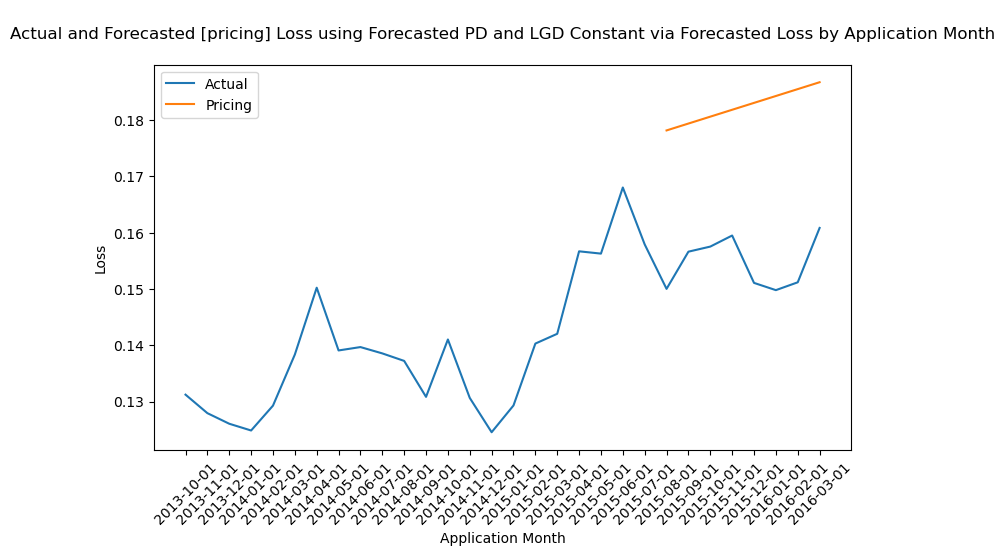

In [30]:
# plot
str_title = f"""
Actual and Forecasted [pricing] Loss using Forecasted PD and LGD Constant via Forecasted Loss by Application Month
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Application Month')
ax.set_ylabel('Loss')
ax.plot(df_grouped['applicationdate__app'], df_grouped['target'], label='Actual')
ax.plot(df_grouped['applicationdate__app'], df_grouped['forecasted_pricing'], label='Pricing')
ax.set_xticklabels(df_grouped['applicationdate__app'], rotation=45)
plt.legend()
plt.show()

### Clean-up

In [31]:
list_str_filename = [
    'cls_model_preprocessing.pkl',
    'preprocessing.py',
]
for str_filename in list_str_filename:
    try:
        os.remove(str_filename)
    except:
        pass